# Paper: ECG-Age for Cardiovascular Outcome Prediction: Evaluation in an Adult Congenital Heart Disease Cohort
## Predict ECG-Age and evaluate the results
### Seyedeh Somayyeh Mousavi
### Sep 2026
### Emory University
### bmemousavi@gmail.com¶

In [8]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys
import pickle
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import shap

# Define Path and Variables

In [9]:
input_path1 = '../../model_and_metadata/'
input_file1 = 'inference_mode_pretrained_model_outputs_cinc2026.csv'
record_var = 'FileID'
target_var = 'Age'
predicted_var = 'ECG-Age'

# Load test dataset

In [10]:
ECG_Age = pd.read_csv(os.path.join(input_path1, input_file1))
drop_columns= [record_var, target_var]
X_test = ECG_Age.drop(columns=drop_columns)
y_test = ECG_Age[target_var]
df_output = ECG_Age[[record_var, target_var]].copy()

# Load the pre trained model

In [11]:
model_name = 'best_model_catboost_ml_cinc2026.pkl'
with open((input_path1 + model_name), 'rb') as f:
    model = pickle.load(f)

# Test the model

In [12]:
y_pred = np.round(model.predict(X_test), 3)
df_output[predicted_var] = y_pred
df_output

,FileID,Age,ECG-Age
0,JS00001,85,82.766
1,JS00002,59,37.649
2,JS00004,66,56.294
3,JS00005,73,57.143
4,JS00006,46,47.009


# Evaluate the results

In [13]:
y_test = df_output[target_var].values
y_pred = df_output[predicted_var].values
y_error = df_output[target_var] - df_output[predicted_var]

results = {

    'N_records': int(len(y_error)),
    'ME': np.mean(y_error),
    'STD_ME': np.std(y_error),
    'MAE': np.mean(np.abs(y_error)),
    'STD_MAE': np.std(np.abs(y_error)),
    'R': pearsonr(y_pred, y_test)[0], 
    
}

print("--- Model Performance Metrics ---")
results_table = pd.DataFrame([results]).round(2)
results_table

--- Model Performance Metrics ---


,N_records,ME,STD_ME,MAE,STD_MAE,R
0,5,9.63,8.3,10.03,7.8,0.84


# Visualizing ECG-age predictions

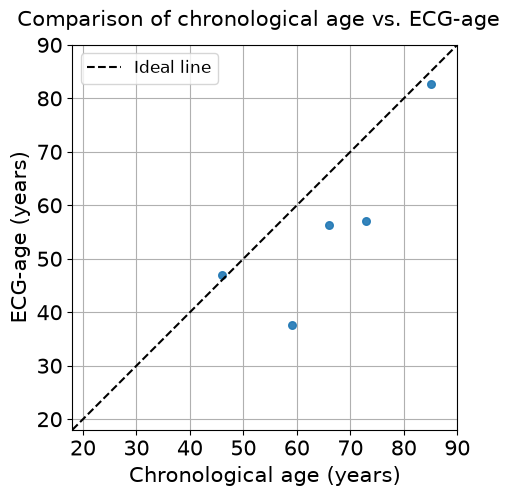

In [14]:
min_val = 18
max_val = 90

x = df_output[target_var].values      # chronological age
y = df_output[predicted_var].values   # ECG-age

fig, ax0_main = plt.subplots(figsize=(5,5))
ax0_main.scatter(x, y, s=30, color='tab:blue', alpha=0.9)
ax0_main.plot([min_val, max_val], [min_val, max_val], '--k', label='Ideal line')
ax0_main.set_xlabel('Chronological age (years)', fontsize=15)
ax0_main.set_ylabel('ECG-age (years)', fontsize=15)
ax0_main.set_xlim(min_val, max_val)
ax0_main.set_ylim(min_val, max_val)
ax0_main.set_aspect('equal')
ax0_main.grid(True)
ax0_main.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax0_main.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax0_main.tick_params(axis='both', which='major', labelsize=15)
ax0_main.legend(fontsize=12)

fig.suptitle('Comparison of chronological age vs. ECG-age', fontsize=15, y=0.95)
plt.show()

# Explaining ECG-age predictions with SHAP

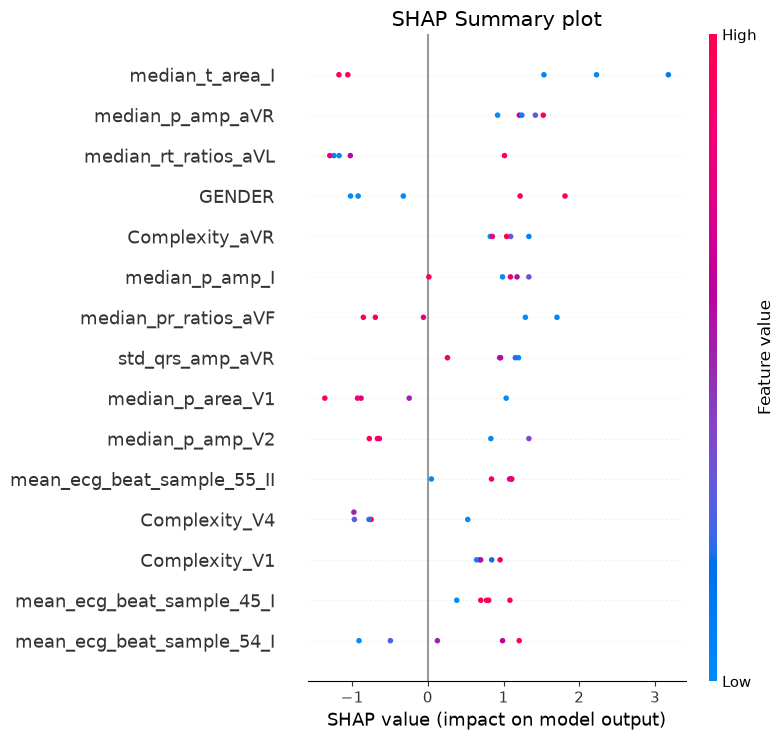

In [15]:
max_f_shapvalues = 15
explainer = shap.TreeExplainer(model)
shap_value = explainer.shap_values(X_test)      
feature_names = X_test.columns

plt.figure(figsize=(10, 8))
shap.summary_plot(
            shap_value, X_test, 
            feature_names = feature_names, 
                max_display = max_f_shapvalues, show=False
)
plt.title('SHAP Summary plot', fontsize=15)
plt.tight_layout()
plt.show()